## 1. Introduction

The goal of this notebook is to **predict traffic accident severity** by leveraging both **structured data** (such as weather, time, and location) and **unstructured textual descriptions** from crash reports.

I compare multiple modeling approaches—including **Logistic Regression**, **Random Forest**, **XGBoost**, and a **DistilBERT-based embedding model**—to evaluate how text features like TF-IDF and Transformer embeddings enhance predictive performance and computational efficiency.

## 2. Import Libraries & Data

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.decomposition import PCA
import time

In [2]:
df = pd.read_csv("../data/accidents_sm.csv")
df.head()

,ID,Severity,Start_Time,State,City,County,Temperature(F),Visibility(mi),Weather_Condition,Sunrise_Sunset,Description,Distance(mi),Start_Lat,Start_Lng,Amenity,Bump,Crossing,Junction,Traffic_Signal
0,A-7169203,Minor,2020-04-10T17:36:07Z,TN,Nashville,Davidson,57.0,10.0,Fair,Day,At TN-254/Old Hickory Blvd - Accident.,0.0,36.053610,-86.715090,False,False,True,False,True
1,A-7121247,Minor,2020-03-18T19:10:02Z,CA,San Jose,Santa Clara,51.0,10.0,Light Rain,Day,At Stevens Creek Blvd - Accident. Hard shoulde...,0.0,37.323280,-121.940560,False,False,False,False,False
2,A-7031663,Minor,2020-05-15T16:10:30Z,AZ,Phoenix,Maricopa,87.0,10.0,Fair,Day,At AZ-101-LOOP/N 7th Ave - Accident.,0.0,33.668110,-112.082880,False,False,True,False,True
3,A-7039213,Minor,2020-05-19T08:22:19Z,WA,Renton,King,55.0,9.0,Cloudy,Day,At 30th St/Exit 6 - Accident. Hard shoulder bl...,0.0,47.516370,-122.198320,False,False,False,False,False
4,A-564983,Minor,2022-07-15T12:12:12Z,NV,Reno,Washoe,92.0,10.0,Fair,Day,Crash on NV-431 Mt Rose Hwy at Caswell Ln.,0.0,39.377449,-119.834717,False,False,False,False,False


## 3. Data Overview & EDA

This dataset is a **sampled subset of the US Accidents (March 2023)** dataset from Kaggle, containing approximately **9,000 traffic crash records** across multiple states.

Each record represents an individual accident event, enriched with **temporal**, **environmental**, and **geospatial** attributes.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 9000 non-null   object 
 1   Severity           9000 non-null   object 
 2   Start_Time         9000 non-null   object 
 3   State              9000 non-null   object 
 4   City               8999 non-null   object 
 5   County             9000 non-null   object 
 6   Temperature(F)     8833 non-null   float64
 7   Visibility(mi)     8835 non-null   float64
 8   Weather_Condition  8836 non-null   object 
 9   Sunrise_Sunset     8980 non-null   object 
 10  Description        9000 non-null   object 
 11  Distance(mi)       9000 non-null   float64
 12  Start_Lat          9000 non-null   float64
 13  Start_Lng          9000 non-null   float64
 14  Amenity            9000 non-null   bool   
 15  Bump               9000 non-null   bool   
 16  Crossing           9000 

### Target Variable (Severity)
The **Severity** column represents the seriousness of each traffic accident.
We have grouped it into **three levels**:
- **Minor** — low impact (original level 1)
- **Moderate** — moderate impact (original level 2)
- **Severe** — high impact or fatal (original levels 3–4)

Because we applied **stratified sampling** during data prepar on,  
the dataset now has a **balanced class distribution**, ensuring fair model training.


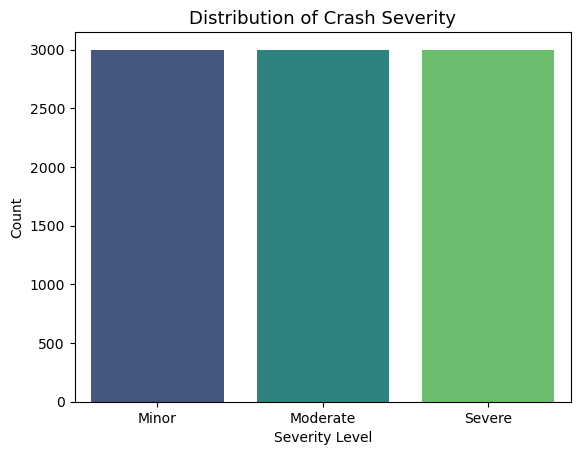

In [8]:
sns.countplot(
    x="Severity",
    data=df,
    hue="Severity",     
    palette="viridis",
    legend=False         
)
plt.title("Distribution of Crash Severity", fontsize=13)
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.show()

In [10]:
# Convert Start_Time once for all temporal features
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['hour'] = df['Start_Time'].dt.hour
df['day_of_week'] = df['Start_Time'].dt.day_name()
df['month'] = df['Start_Time'].dt.month

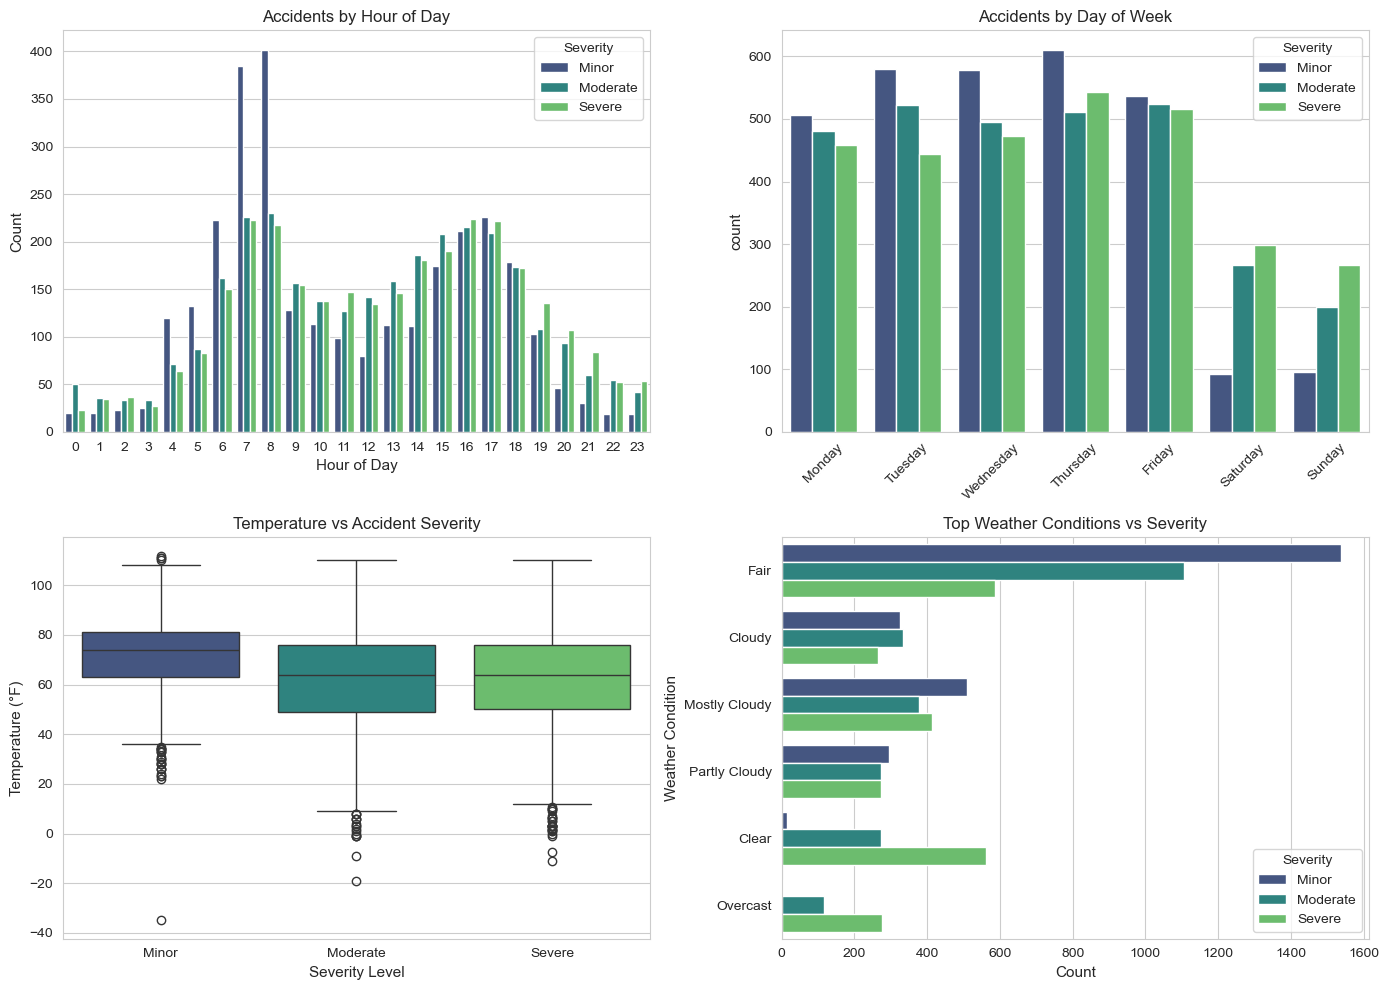

In [12]:
sns.set_style("whitegrid")
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

# ---- Create 2×2 subplot grid ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Severity by Time of Day
sns.countplot(x='hour', hue='Severity', data=df, palette='viridis', ax=axes[0,0])
axes[0,0].set_title("Accidents by Hour of Day")
axes[0,0].set_xlabel("Hour of Day")
axes[0,0].set_ylabel("Count")

# Severity by Day of Week
sns.countplot(x='day_of_week', hue='Severity', data=df,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
              palette='viridis', ax=axes[0,1])
axes[0,1].set_title("Accidents by Day of Week")
axes[0,1].set_xlabel("")
axes[0,1].tick_params(axis='x', rotation=45)

# Severity by Temperature
sns.boxplot(x='Severity', y='Temperature(F)',hue ='Severity',data=df.dropna(subset=['Temperature(F)']), palette='viridis', ax=axes[1,0])
axes[1,0].set_title("Temperature vs Accident Severity")
axes[1,0].set_xlabel("Severity Level")
axes[1,0].set_ylabel("Temperature (°F)")

# Severity by Weather Condition (Top 6)
top_weather = df['Weather_Condition'].value_counts().nlargest(6).index
sns.countplot(y='Weather_Condition', hue='Severity', 
              data=df[df['Weather_Condition'].isin(top_weather)], 
              palette='viridis', ax=axes[1,1])
axes[1,1].set_title("Top Weather Conditions vs Severity")
axes[1,1].set_xlabel("Count")
axes[1,1].set_ylabel("Weather Condition")

plt.tight_layout()
plt.show()

### Patterns Between Accident Severity and Key Factors

* **Hour of Day:** Crashes peak around **7–8 AM** and **4–6 PM**, matching rush hours. Frequency is high, but severity stays fairly consistent.
* **Day of Week:** **Weekdays** show more crashes, especially **Wednesday–Friday**, while **weekends** have fewer but slightly more severe cases.
* **Temperature:** Accidents occur across all temperatures; a few severe cases appear in **extreme cold**.
* **Weather Condition:** Most crashes happen in **clear or fair weather**, but **rain and clouds** are linked to **higher severity**.


## 4. Data Preprocessing

### Handle Missing Values

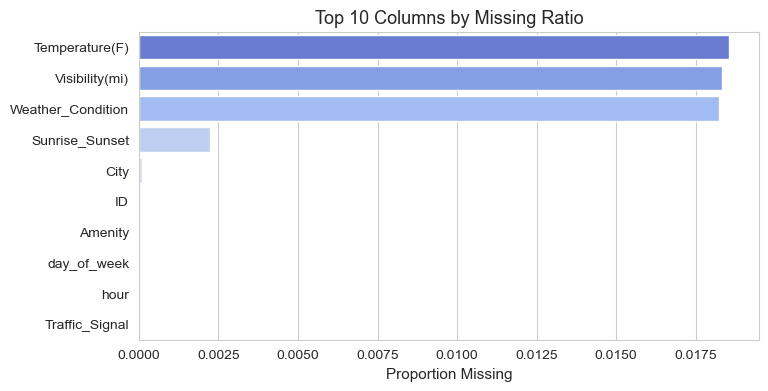

In [14]:
missing = df.isna().mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))
sns.barplot(
    y=missing.index,         
    x=missing.values,        
    palette='coolwarm',
    hue=missing.index,     
    dodge=False,
    legend=False             
)
plt.title("Top 10 Columns by Missing Ratio", fontsize=13)
plt.xlabel("Proportion Missing")
plt.ylabel("")                
plt.show()

In [15]:
def forward(self, X):
    self.hidden_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
    self.hidden_output = self.sigmoid(self.hidden_input)
    self.final_input = np.dot(self.hidden_output, self.weights_hidden_output) + self.bias_output
    self.final_output = self.softmax(self.final_input)
    return self.final_output

Because of low missingess (mostly under ~2%), we use median/mode imputation

In [16]:
num_cols = ['Temperature(F)', 'Visibility(mi)', 'Distance(mi)']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
cat_cols = ['State', 'City', 'Weather_Condition', 'Sunrise_Sunset']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

## 5. Feature Engineering

### Simplify or drop high-cardinality features

In [18]:
# Map state to region
region_map = {
    'Northeast': ['ME', 'NH', 'VT', 'MA', 'RI', 'CT', 'NY', 'NJ', 'PA'],
    'Midwest': ['OH', 'MI', 'IN', 'IL', 'WI', 'MN', 'IA', 'MO', 'ND', 'SD', 'NE', 'KS'],
    'South': ['DE', 'MD', 'VA', 'WV', 'KY', 'NC', 'SC', 'TN', 'GA', 'FL', 'AL', 'MS', 'AR', 'LA', 'TX', 'OK'],
    'West': ['MT', 'ID', 'WY', 'CO', 'NM', 'AZ', 'UT', 'NV', 'CA', 'OR', 'WA', 'AK', 'HI']
}

def map_region(state):
    for region, states in region_map.items():
        if state in states:
            return region
    return 'Other'

df['Region'] = df['State'].apply(map_region)

# Weekend or not based on EDA
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

# Drop high-cardinality columns
df = df.drop(['City', 'County'], axis=1)

### Drop unsed columns

In [20]:
df.drop(columns=['ID', 'Start_Time', 'State', 'day_of_week'], inplace=True, errors='ignore')

### Text Cleaning

In [22]:
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

df["clean_description"] = df["Description"].apply(clean_text)

### Convert text to TF-IDF features

In [24]:
tfidf = TfidfVectorizer(max_features=1000)
tfidf_features = tfidf.fit_transform(df['clean_description'])
tfidf_df = pd.DataFrame(tfidf_features.toarray(), columns=tfidf.get_feature_names_out())

### Convert text to DistilBERT Embeddings

In [30]:
import warnings
warnings.filterwarnings('ignore')
# Load pretrained model
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")

# Prepare text input (use the same column used for TF-IDF)
texts = df['clean_description'].fillna("").tolist()

# Tokenize and get embeddings
inputs = tokenizer(texts, return_tensors='pt', truncation=True, padding=True, max_length=64)

with torch.no_grad():
    outputs = model(**inputs)

# Average pool over token embeddings to get sentence embedding
bert_embeddings = outputs.last_hidden_state.mean(dim=1).numpy()

# Optional dimensionality reduction
pca = PCA(0.95, random_state=42)  # keep 95% of variance
bert_reduced = pca.fit_transform(bert_embeddings)
bert_df = pd.DataFrame(bert_reduced, columns=[f'bert_{i+1}' for i in range(bert_reduced.shape[1])])

### Encode Categorical Variables

In [31]:
# One-hot encode selected categorical predictors
cat_features = ['Region', 'Weather_Condition', 'Sunrise_Sunset']
df = pd.get_dummies(df, columns=cat_features, drop_first=True)

### Feature Scaling

In [32]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

### Final Feature Sets

In [35]:
# Structured-only dataset (baseline)
df_structured = df.drop(columns=['Description', 'clean_description'])

# TF-IDF + structured
df_final_tf = pd.concat([df.drop(columns=['Description', 'clean_description']),
                      tfidf_df], axis=1)
# DistilBERT embeddings + structured
df_final_bert = pd.concat([
    df.drop(columns=['Description', 'clean_description']),  # structured features
    bert_df  # new Transformer embeddings
], axis=1)

### Train-Test Split

In [58]:
# Common target
y = df['Severity']
le = LabelEncoder()
y = le.fit_transform(y)

# Helper function to split any dataset
def stratified_split(df_input, y, test_size=0.3, seed=42):
    X_train, X_test, y_train, y_test = train_test_split(
        df_input, y, test_size=test_size, stratify=y, random_state=seed
    )
    return X_train, X_test, y_train, y_test

# Structured
X_train_s, X_test_s, y_train_s, y_test_s = stratified_split(
    df_structured.drop(columns=['Severity']), y)

# TF-IDF
X_train_tf, X_test_tf, y_train_tf, y_test_tf = stratified_split(
    df_final_tf.drop(columns=['Severity']), y)

# BERT
X_train_b, X_test_b, y_train_b, y_test_b = stratified_split(
    df_final_bert.drop(columns=['Severity']), y)

print(f"Structured: {X_train_s.shape}, TF-IDF: {X_train_tf.shape}, BERT: {X_train_b.shape}")


Structured: (6300, 63), TF-IDF: (6300, 1063), BERT: (6300, 236)


## 6.  Model Comparison: Structured vs Text Features

In [85]:
warnings.filterwarnings('ignore')

# ==============================
# Define Models
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# ==============================
# Define Datasets
# ==============================
datasets = {
    "Structured": (X_train_s, X_test_s, y_train_s, y_test_s),
    "TF-IDF": (X_train_tf, X_test_tf, y_train_tf, y_test_tf),
    "BERT": (X_train_b, X_test_b, y_train_b, y_test_b)
}

# ==============================
# Train Models and Store Results
# ==============================
results = []

for data_name, (X_train, X_test, y_train, y_test) in datasets.items():
    for model_name, model in models.items():
        start_time = time.time()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        elapsed = time.time() - start_time

        results.append({
            "Dataset": data_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred, average='macro'),
            "Time (s)": round(elapsed, 2)
        })

results_df = pd.DataFrame(results)
print("\nModel Performance Summary:")
print(results_df)


Model Performance Summary:
       Dataset                Model  Accuracy        F1  Time (s)
0   Structured  Logistic Regression  0.591111  0.581552      3.79
1   Structured        Random Forest  0.697407  0.693991      1.25
2   Structured              XGBoost  0.707037  0.703658      0.36
3   Structured       Neural Network  0.645185  0.638000     10.26
4       TF-IDF  Logistic Regression  0.825185  0.824200     23.89
5       TF-IDF        Random Forest  0.865185  0.864391      3.44
6       TF-IDF              XGBoost  0.873704  0.872946      2.66
7       TF-IDF       Neural Network  0.747407  0.750583     34.38
8         BERT  Logistic Regression  0.834815  0.833831      6.97
9         BERT        Random Forest  0.810370  0.807743     11.08
10        BERT              XGBoost  0.853333  0.851784      3.29
11        BERT       Neural Network  0.794815  0.795024     25.77


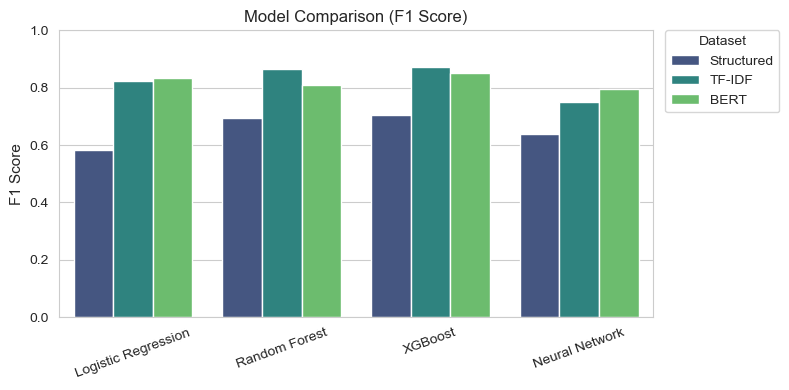

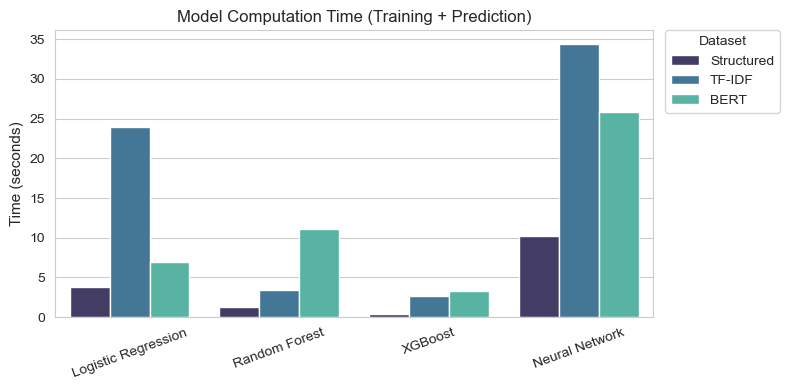

In [89]:
plt.figure(figsize=(8, 4))
sns.barplot(x="Model", y="F1", hue="Dataset", data=results_df, palette="viridis")
plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.xlabel("")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(
    title="Dataset",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x="Model", y="Time (s)", hue="Dataset", data=results_df, palette="mako")
plt.title("Model Computation Time (Training + Prediction)")
plt.ylabel("Time (seconds)")
plt.xlabel("")
plt.xticks(rotation=20)
plt.legend(
    title="Dataset",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)
plt.tight_layout()
plt.show()

###  Summary

- Incorporating text features clearly improves model performance across all classifiers.
- The TF-IDF representation produced **1,063 features**, while the DistilBERT embeddings (after PCA) reduced this to **236 dense features**.
- Although both text-based representations outperform the structured-only baseline, **BERT achieves comparable or better F1-scores with fewer features**, demonstrating its ability to capture richer semantic information in a compact form.
- In terms of computation time, **Logistic Regression and Neural Networks** trained on TF-IDF features show the highest cost due to the large sparse feature space, whereas **BERT-based models are more computationally efficient once embeddings are generated**.
- Overall, these results suggest that **BERT embeddings not only enhance predictive accuracy but also offer better scalability and efficiency** compared with traditional TF-IDF text representations.

## Textual Indicators of Crash Severity

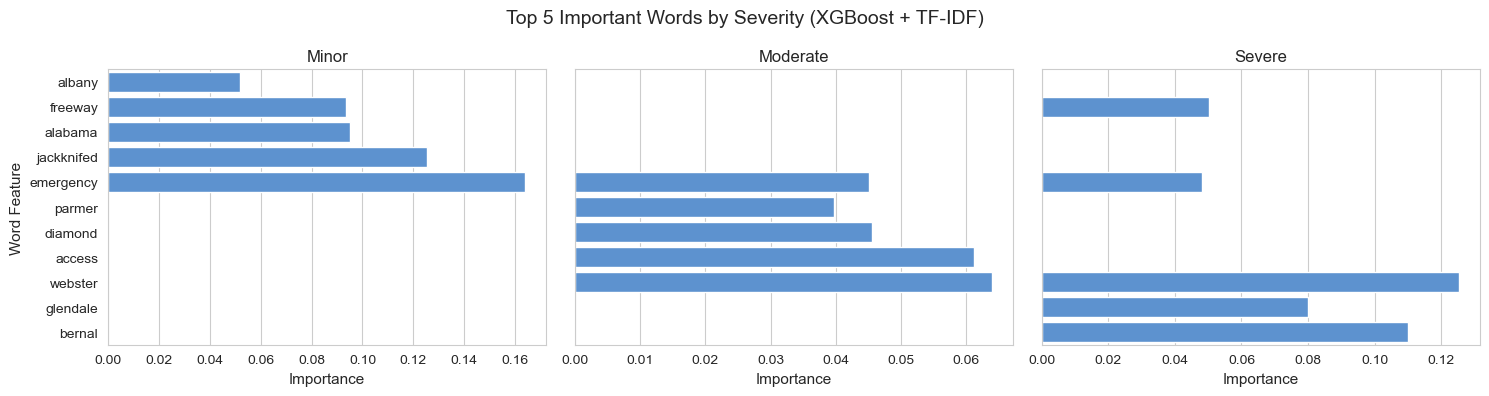

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from xgboost import XGBClassifier

feature_names = np.array(tfidf.get_feature_names_out())

# Replace numeric codes with descriptive labels
severity_labels = {0: "Minor", 1: "Moderate", 2: "Severe"}
classes = np.unique(y_train_tf)

fig, axes = plt.subplots(1, len(classes), figsize=(15, 4), sharey=True)
sns.set_style("whitegrid")

for i, target_class in enumerate(classes):
    y_binary = (y_train_tf == target_class).astype(int)
    xgb_class = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb_class.fit(X_train_tf, y_binary)
    
    importances = xgb_class.feature_importances_
    top_idx = np.argsort(importances)[-5:]
    
    sns.barplot(
        x=importances[top_idx],
        y=feature_names[top_idx],
        color="#4A90E2",
        ax=axes[i]
    )
    axes[i].set_title(f"{severity_labels.get(target_class, target_class)}", fontsize=12)
    axes[i].set_xlabel("Importance")
    if i == 0:
        axes[i].set_ylabel("Word Feature")
    else:
        axes[i].set_ylabel("")

plt.suptitle("Top 5 Important Words by Severity (XGBoost + TF-IDF)", fontsize=14)
plt.tight_layout()
plt.show()

Each **severity level exhibits distinct word patterns.** 

For **minor crashes**, terms like emergency and jackknifed were most influential, likely reflecting reports describing incidents requiring assistance but resulting in limited damage.

**Moderate crashes** were linked to words such as access and diamond, which may reference roadway features or intersections where moderate collisions tend to occur.

**Severe crashes** were strongly associated with freeway and emergency, consistent with the higher speeds and emergency responses typical of serious incidents.

However, several of the top-ranked words are location names rather than descriptive crash terms, suggesting that the textual data may contain noise or geographic bias. This indicates that further text refinement, such as normalizing location entities, could improve interpretability and model robustness.